# Train the chromHMM multiclass classification model

## Set up wandb

In [1]:
import wandb
import pandas as pd
import torch
import numpy as np
import os
wandb.login(host="https://api.wandb.ai")
project_name = 'human-chromhmm-fullstack'
os.environ["WANDB_NOTEBOOK_NAME"] = "/code/github/gReLU-applications/chromhmm/2_model.ipynb"

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: avantikalal (grelu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [2]:
run = wandb.init(
    entity='grelu', project=project_name, job_type='training', name='train', 
    settings=wandb.Settings(
        program_relpath='2_model.ipynb',
        program_abspath='/code/github/gReLU-applications/chromhmm/2_model.ipynb')
)

## Load data

In [3]:
artifact = run.use_artifact('dataset:latest')
dir = artifact.download()

chromhmm = pd.read_csv(dir + '/data.csv.gz')
chromhmm['state'] = chromhmm['state'].astype('category')
chromhmm.head()

wandb:   1 of 1 files downloaded.  


,chrom,start,end,state,interval_idx,enformer_split,split
0,chr1,792508,793532,GapArtf,0,NaN,train
1,chr1,793908,794932,Acet,1,NaN,train
2,chr1,794408,795432,EnhWk,2,NaN,train
3,chr1,795908,796932,Quies,3,NaN,train
4,chr1,798608,799632,GapArtf,4,NaN,train


In [4]:
chromhmm.state.value_counts()

state
Quies      1485576
Acet        639669
EnhA        613794
ReprPC      610147
Tx          561526
EnhWk       543113
HET         521161
TxWk        254518
TxEnh       190465
TxEx        121833
PromF        88429
GapArtf      51474
BivProm      48242
znf          34146
TSS          24402
DNase        20609
Name: count, dtype: int64

## Downsample

In [5]:
out = pd.DataFrame()
rng = np.random.RandomState(0)

for state in chromhmm.state.unique():
    if np.sum(chromhmm.state == state) > 250000:
        out = pd.concat([out, chromhmm[chromhmm.state==state].sample(
            250000, random_state=rng)])
    else:
        out = pd.concat([out, chromhmm[chromhmm.state==state]])

chromhmm = out.reset_index(drop=True).copy()
chromhmm.state.value_counts()

state
Acet       250000
EnhA       250000
EnhWk      250000
HET        250000
Quies      250000
ReprPC     250000
Tx         250000
TxWk       250000
TxEnh      190465
TxEx       121833
PromF       88429
GapArtf     51474
BivProm     48242
znf         34146
TSS         24402
DNase       20609
Name: count, dtype: int64

## Split

In [6]:
train_intervals = chromhmm.loc[chromhmm.split=='train', ['chrom', 'start', 'end', 'state']].reset_index(drop=True)
val_intervals = chromhmm.loc[chromhmm.split=='valid', ['chrom', 'start', 'end', 'state']].reset_index(drop=True)
test_intervals = chromhmm.loc[chromhmm.split=='test', ['chrom', 'start', 'end', 'state']].reset_index(drop=True)

print(len(train_intervals), len(val_intervals), len(test_intervals))

2230362 163688 185550


## Make pytorch datasets

In [7]:
import grelu.data.dataset
train_dataset = grelu.data.dataset.DFSeqDataset(
    train_intervals,
    genome='hg38',
    rc=True, # reverse complement
    max_seq_shift=3, # Shift the sequence
    augment_mode="random", # Randomly select which augmentations to apply
)

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sequences will be extracted from columns ['chrom', 'start', 'end']
Labels are being treated as class names for multiclass classification.


In [8]:
val_dataset = grelu.data.dataset.DFSeqDataset(val_intervals, genome='hg38')

print(len(train_dataset), len(val_dataset))

Sequences will be extracted from columns ['chrom', 'start', 'end']
Labels are being treated as class names for multiclass classification.
2230362 163688


In [9]:
print(train_dataset.labels.shape)
print(train_dataset.labels[:3].squeeze())

(2230362, 16, 1)
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


## Inversely weight classes

In [10]:
class_prop = train_dataset.labels.squeeze().mean(0)
class_weights = 1/(class_prop*10)
class_weights

array([ 1.0071764,  5.430636 , 12.622309 ,  1.0177703,  1.0143404,
        4.821779 ,  1.077121 ,  2.9666567,  1.0206438,  1.0360477,
       10.866564 ,  1.0241259,  1.3642693,  2.1729102,  1.018658 ,
        8.760603 ], dtype=float32)

## Build model

In [11]:
model_params = {
    'model_type':'EnformerPretrainedModel',
    'n_tasks': len(chromhmm.state.unique()),
    'crop_len': 0,
    'n_transformers': 1,
}

train_params = {
    'task':'multiclass',
    'lr':1e-4,
    'logger': 'wandb',
    'batch_size': 512,
    'num_workers': 16,
    'devices': 4,
    'save_dir': project_name,
    'optimizer': 'adam',
    'max_epochs': 10,
    'class_weights':class_weights,
}

import grelu.lightning
model = grelu.lightning.LightningModel(model_params=model_params, train_params=train_params) 

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.
wandb: Downloading large artifact human_state_dict:latest, 939.29MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.7
/opt/conda/lib/python3.11/site-packages/grelu/model/models.py:771: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use cas

## Train model

In [12]:
trainer = model.train_on_dataset(train_dataset, val_dataset)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Validation DataLoader 0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 320/320 [00:46<00:00,  6.87it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.07802204042673111    │
│         val_auroc         │    0.5256534814834595     │
│        val_avgprec        │    0.07628291845321655    │
│         val_loss          │     4.513631343841553     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

  | Name         | Type                    | Params | Mode 
-----------------------------------------------------------------
0 | model        | EnformerPretrainedModel | 71.5 M | train
1 | loss         | CrossEntropyLoss        | 0      | train
2 | activation   | Softmax                 | 0      | train
3 | val_metrics  | MetricCollection        | 0      | train
4 | test_metrics | MetricCollection        | 0      | train
5 | transform    | Identity                | 0      | train
-----------------------------------------------------------------
71.5 M    Trainable params
0         Non-trainable params
71.5 M    Total params
285.968   Total estimated model params size (MB)
239       Modules in train mode
0         Modules in eval mode


/opt/conda/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)  # noqa: B028
/opt/conda/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)  # noqa: B028


Epoch 0:  31%|█████████████████████████████████████████████▊                                                                                                        | 1329/4357 [09:01<20:34,  2.45it/s, v_num=9dx7, train_loss_step=2.510]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Epoch 2: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4357/4357 [29:40<00:00,  2.45it/s, v_num=9dx7, train_loss_step=2.710, train_loss_epoch=2.530]
Validation: |                                                                                                                                                                                                        | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4357/4357 [29:40<00:00,  2.45it/s, v_num=9dx7, train_loss_step=2.170, train_loss_epoch=2.470]
Validation: |                                                                                                                                                                                                        | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████████████████████████████████████

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4357/4357 [30:47<00:00,  2.36it/s, v_num=9dx7, train_loss_step=2.090, train_loss_epoch=2.210]


## Load best checkpoint

In [13]:
best_checkpoint = trainer.checkpoint_callback.best_model_path
model = grelu.lightning.LightningModel.load_from_checkpoint(best_checkpoint)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.
wandb: Downloading large artifact human_state_dict:latest, 939.29MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.7
/opt/conda/lib/python3.11/site-packages/grelu/model/models.py:771: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use cas

## Evaluate model

In [14]:
test_dataset = grelu.data.dataset.DFSeqDataset(
    test_intervals, genome="hg38")

test_metrics = model.test_on_dataset(
    test_dataset, devices=4, num_workers=16, batch_size=512,
    write_path='model.ckpt'
)
test_metrics

Sequences will be extracted from columns ['chrom', 'start', 'end']
Labels are being treated as class names for multiclass classification.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Testing DataLoader 0: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 363/363 [00:52<00:00,  6.89it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.4372537434101105     │
│        test_auroc         │     0.860890805721283     │
│       test_avgprec        │    0.41129541397094727    │
│         test_loss         │    3.1207919120788574     │
└───────────────────────────┴───────────────────────────┘

,test_accuracy,test_auroc,test_avgprec
Acet,0.293946,0.797298,0.209121
BivProm,0.543125,0.937343,0.357540
DNase,0.852816,0.990528,0.752660
EnhA,0.294986,0.814504,0.336752
EnhWk,0.268325,0.814422,0.294704
GapArtf,0.798767,0.951664,0.702935
HET,0.245460,0.823602,0.498241
PromF,0.593959,0.955657,0.636856
Quies,0.366163,0.851176,0.360967
ReprPC,0.287436,0.765248,0.252218


In [15]:
probs = model.predict_on_dataset(test_dataset, devices=0, num_workers=16, batch_size=1024)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 182/182 [01:53<00:00,  1.61it/s]


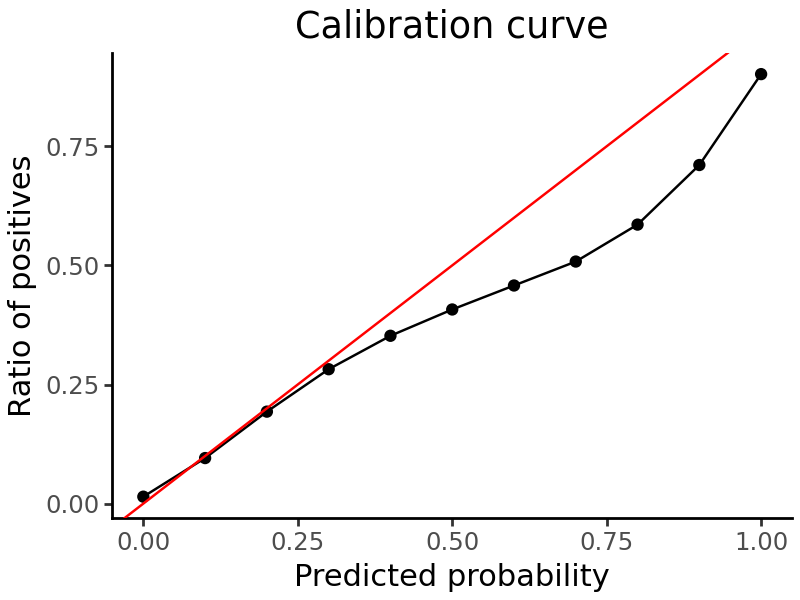

In [16]:
import grelu.visualize

grelu.visualize.plot_calibration_curve(
    probs,
    test_dataset.labels,
    figsize=(4,3)
)

## Save

In [17]:
artifact = wandb.Artifact('model', type='model')
artifact.add_file('model.ckpt', 'model.ckpt') 
run.log_artifact(artifact)

<Artifact model>

In [18]:
run.log_code()

wandb: WARNING No relevant files were detected in the specified directory. No code will be logged to your run.


In [19]:
run.finish()

epoch,▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇█
train_loss_epoch,█▅▅▄▄▃▂▂▁▁
train_loss_step,▆▆▅▂█▅▄▂▃▃▃▂▄▆▃▅▅▃▅▅▇▂▄▂▂▄▃▂▂▂▃▄▂▁▃▂▃▂▁▂
trainer/global_step,▁▁▁▁▂▂▂▂▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█
val_accuracy,▁██████████
val_auroc,▁██████████
val_avgprec,▁██████████
val_loss,█▁▁▁▁▁▁▁▁▁▂
epoch,9
train_loss_epoch,2.21395
train_loss_step,2.35459
